# Session 09 InClass Exercise

This notebook is split into seven sections:
1. Data Prep & EDA
2. K-Means Clustering
3. PCA for Visualization
4. K-Means Clustering (Round 2)
5. PCA for Visualization (Round 2)
6. EDA on Clusters
7. Make Recommendations

## 0. Goal & Scope

**GOAL**: You are trying to better understand the company’s different segments of employees and how to increase employee retention within each segment.

**SCOPE**: Your task is to use a clustering technique to segment the employees, a dimensionality reduction technique to visualize the segments, and finally explore the clusters to make recommendations to increase retention.

## 1. Data Prep & EDA

### a. Data Prep: Check the data types

The data can be found in the `employee_data.csv` file.

In [1]:
# read in the employee data
import pandas as pd
import numpy as np
df = pd.read_csv('employee_data.csv')

In [2]:
# note the number of rows and columns
print(f"Dataset shape: {df.shape}")

Dataset shape: (1470, 10)


In [3]:
# view the data types of all the columns
print(df.dtypes)

EmployeeID            int64
Age                   int64
Gender               object
DistanceFromHome      int64
JobLevel              int64
Department           object
MonthlyIncome         int64
PerformanceRating     int64
JobSatisfaction       int64
Attrition            object
dtype: object


In [4]:
# look at the numeric columns
print(df.describe())

        EmployeeID          Age  DistanceFromHome     JobLevel  MonthlyIncome  \
count  1470.000000  1470.000000       1470.000000  1470.000000    1470.000000   
mean   2024.865306    36.923810          9.192517     2.063946    6502.931293   
std     602.024335     9.135373          8.106864     1.106940    4707.956783   
min    1001.000000    18.000000          1.000000     1.000000    1009.000000   
25%    1491.250000    30.000000          2.000000     1.000000    2911.000000   
50%    2020.500000    36.000000          7.000000     2.000000    4919.000000   
75%    2555.750000    43.000000         14.000000     3.000000    8379.000000   
max    3068.000000    60.000000         29.000000     5.000000   19999.000000   

       PerformanceRating  JobSatisfaction  
count        1470.000000      1470.000000  
mean            3.153741         2.728571  
std             0.360824         1.102846  
min             3.000000         1.000000  
25%             3.000000         2.000000  
50%   

In [5]:
# look at the non-numeric columns
print(df.select_dtypes(include=['object']).describe())

       Gender              Department Attrition
count    1470                    1470      1470
unique      2                       3         2
top      Male  Research & Development        No
freq      882                     961      1233


### b. Data Prep: Convert the data types

Use `np.where` and `pd.get_dummies` to create a DataFrame for modeling where all fields are numeric.

In [6]:
# create a copy of the dataframe
df_clean = df.copy()

In [7]:
# look at the gender values
print(df_clean['Gender'].value_counts())

Gender
Male      882
Female    588
Name: count, dtype: int64


In [8]:
# change gender into a numeric field using np.where
df_clean['Gender'] = np.where(df_clean['Gender'] == 'Male', 1, 0)

In [9]:
# look at the attrition values
print(df_clean['Attrition'].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [10]:
# change attrition to a numeric field using np.where
df_clean['Attrition'] = np.where(df_clean['Attrition'] == 'Yes', 1, 0)

In [11]:
# look at the department values
print(df_clean['Department'].value_counts())

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


In [12]:
# change department to a numeric field via dummy variables
dept_dummies = pd.get_dummies(df_clean['Department'], prefix='Dept')

In [13]:
# attach the columns back on to the dataframe
df_clean = pd.concat([df_clean, dept_dummies], axis=1)

In [14]:
# extra: drop the original department column
df_clean = df_clean.drop('Department', axis=1)

In [15]:
# view the cleaned dataframe
print(df_clean.head())

   EmployeeID  Age  Gender  DistanceFromHome  JobLevel  MonthlyIncome  \
0        1001   41       0                 1         2           5993   
1        1002   49       1                 8         2           5130   
2        1004   37       1                 2         1           2090   
3        1005   33       0                 3         1           2909   
4        1007   27       1                 2         1           3468   

   PerformanceRating  JobSatisfaction  Attrition  Dept_Human Resources  \
0                  3                4          1                 False   
1                  4                2          0                 False   
2                  3                3          1                 False   
3                  3                3          0                 False   
4                  3                2          0                 False   

   Dept_Research & Development  Dept_Sales  
0                        False        True  
1                         

In [16]:
# note the number of rows and columns
print(f"Cleaned dataset shape: {df_clean.shape}")

Cleaned dataset shape: (1470, 12)


### c. EDA

Our goal is to find the different types of employees at the company and take a look at their attrition (whether they end up leaving or not).

In [17]:
# what is the overall attrition for all employees in the data aka what percent of employees leave the company?
attrition_rate = df_clean['Attrition'].mean()
print(f"Overall attrition rate: {attrition_rate:.2%}")

Overall attrition rate: 16.12%


In [18]:
# create a summary table to show the mean of each column for employees who stay vs leave - what are your takeaways?
summary = df_clean.groupby('Attrition').mean()
print(summary.T)

Attrition                              0            1
EmployeeID                   2027.656123  2010.345992
Age                            37.561233    33.607595
Gender                          0.593674     0.632911
DistanceFromHome                8.915653    10.632911
JobLevel                        2.145985     1.637131
MonthlyIncome                6832.739659  4787.092827
PerformanceRating               3.153285     3.156118
JobSatisfaction                 2.778589     2.468354
Dept_Human Resources            0.041363     0.050633
Dept_Research & Development     0.671533     0.561181
Dept_Sales                      0.287105     0.388186


### d. Data Prep: Remove the Attrition and ID Columns

Exclude the attrition column (to be overlayed onto our clusters later on) and the ID column.

In [19]:
# create a new dataframe without the attrition column for us to model on\
# drop the employee column as well before modeling
df_model = df_clean.drop(['Attrition', 'EmployeeID'], axis=1)

In [20]:
# note the number of rows and columns in the dataframe
print(f"Model dataset shape: {df_model.shape}")

Model dataset shape: (1470, 10)


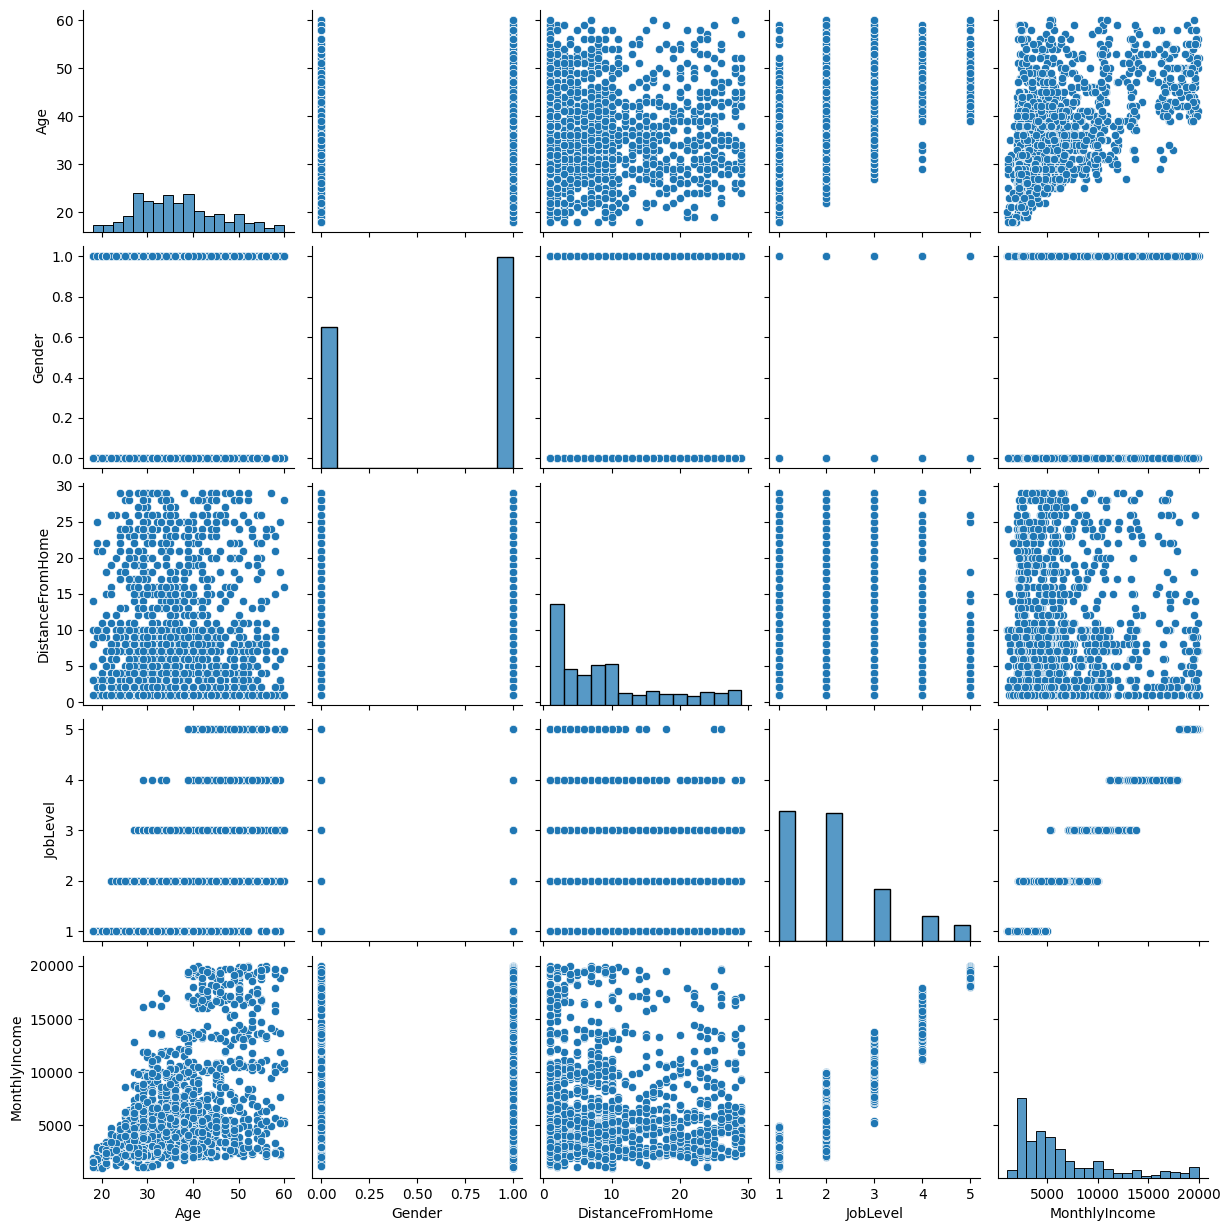

In [21]:
# create a pair plot comparing all the columns of the dataframe - what observations do you notice?
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df_model.iloc[:, :5])  # First 5 columns for speed
plt.show()

#Pairplot Summary

Age: Roughly normal distribution, mostly 25–45 years  indicates a mid-career workforce.

Gender: Binary and balanced; no clear relation to other variables.

DistanceFromHome: Right-skewed  most employees live close to work; no visible correlation with income or job level.

JobLevel: Discrete bands from 1–5; strongly correlated with MonthlyIncome (higher level → higher pay).

MonthlyIncome: Right-skewed; clear step increases by JobLevel; mild growth with Age.

Relationships: Apart from JobLevel–Income, most variables show weak or no linear relationships.

Clustering readiness: Data is well-scaled, not collinear, and suitable for K-Means or PCA segmentation.

Overall patterns  Apart from income–level correlation, variables show weak linear relationships.


## 2. K-Means Clustering

Let's segment the employees using K-Means clustering.

### a. Standardize the data

In [22]:
# scale the data using standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)
# convert back to dataframe
df_scaled = pd.DataFrame(df_scaled, columns=df_model.columns)

In [23]:
# double check that all the column means are 0 and standard deviations are 1
print(df_scaled.mean().round(2))
print(df_scaled.std().round(2))

Age                           -0.0
Gender                         0.0
DistanceFromHome               0.0
JobLevel                      -0.0
MonthlyIncome                 -0.0
PerformanceRating             -0.0
JobSatisfaction               -0.0
Dept_Human Resources           0.0
Dept_Research & Development    0.0
Dept_Sales                     0.0
dtype: float64
Age                            1.0
Gender                         1.0
DistanceFromHome               1.0
JobLevel                       1.0
MonthlyIncome                  1.0
PerformanceRating              1.0
JobSatisfaction                1.0
Dept_Human Resources           1.0
Dept_Research & Development    1.0
Dept_Sales                     1.0
dtype: float64


### b. Write a loop to fit models with 2 to 15 clusters and record the inertia and silhouette scores

In [24]:
# import kmeans and write a loop to fit models with 2 to 15 clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))


Text(0.5, 1.0, 'Elbow Method')

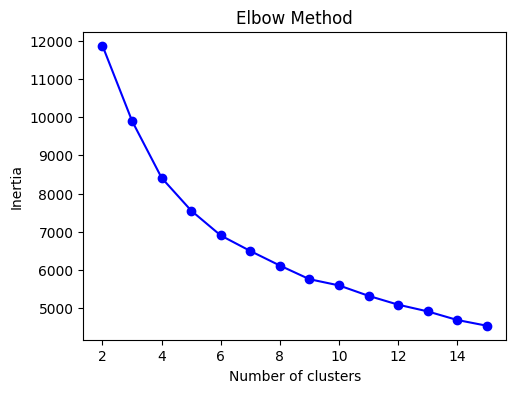

In [25]:
# plot the inertia values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

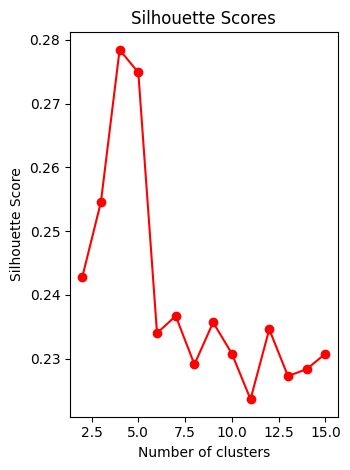

In [26]:
# plot the silhouette scores
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.tight_layout()
plt.show()

### c. Identify a k value that looks like an elbow on the inertia plot and has a high silhouette score

In [27]:
# fit a kmeans model for the k value that you identified
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(df_scaled)
labels = kmeans.labels_

In [28]:
# find the number of employees in each cluster
cluster_counts = pd.Series(labels).value_counts().sort_index()
print("Employees per cluster:", cluster_counts)

Employees per cluster: 0    747
1    407
2    253
3     63
Name: count, dtype: int64


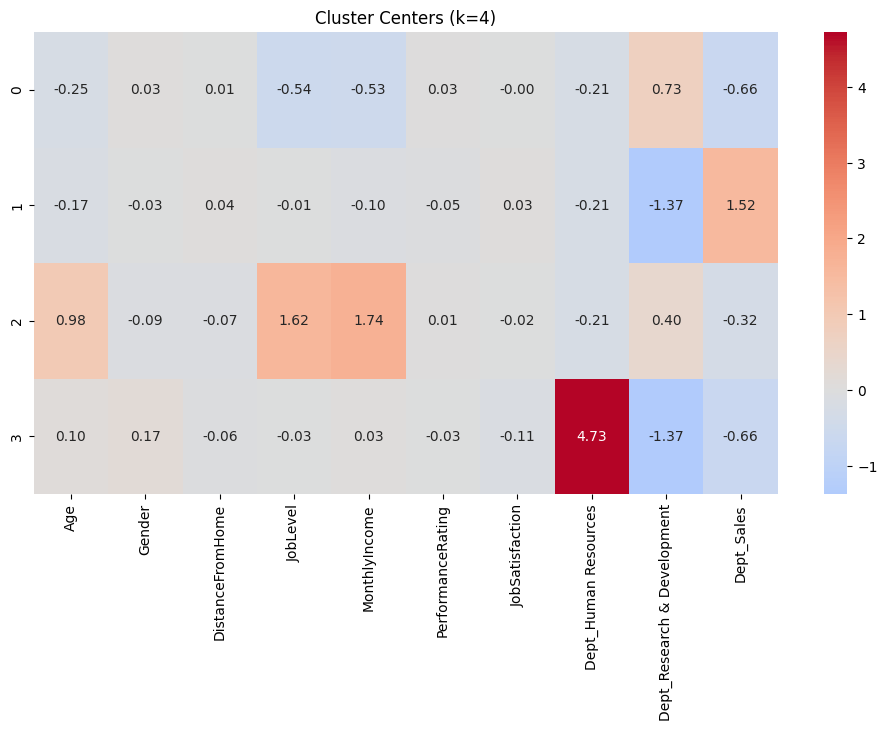

In [29]:
# create a heat map of the cluster centers
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=df_scaled.columns)
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_centers, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title(f'Cluster Centers (k=4)')
plt.show()

### interpret the clusters


# Cluster Interpretation (k = 4)

# Cluster 0 – R&D and Sales Professionals
 - Mainly from Research & Development and Sales departments.
 - Hold higher job levels, indicating managerial or senior technical positions.
 - Moderate age and income levels; experienced but not at the executive level.
 - Balanced satisfaction and performance ratings, suggesting a stable and productive workforce.
 - Represent a core operational segment supporting technical and sales functions.

# Cluster 1 – Cross-Department Junior Employees
 - Spread across all three departments (R&D, Sales, HR) with no dominant specialization.
 - Low job levels and low monthly income, typical of entry-level or early-career employees.
 - Younger demographic, possibly recent hires or support staff.
 - Play foundational roles in routine or departmental operations.
 - Would benefit from training, mentorship, and retention-focused strategies.

# Cluster 2 – Senior Executive Group
 - Characterized by very high job levels and exceptionally high monthly income.
 - Older age group, representing experienced executives or senior management.
 - Appear across multiple departments, indicating cross-functional leadership roles.
 - High performance ratings reflect strong expertise and organizational impact.
 - Represent top-tier leadership responsible for major decisions and strategic direction.

# Cluster 3 – Human Resources Specialists
 - Strong concentration in the Human Resources department.
 - Moderate age and job level but noticeably lower job satisfaction.
 - Average performance ratings; may indicate role fatigue or engagement challenges.
 - Minimal involvement in other departments, emphasizing a focused HR function.
 - This group may benefit from motivation and workload management initiatives.

# Summary:
# The four clusters reveal distinct workforce segments:
# 1. R&D and Sales Professionals – Skilled and stable mid-senior employees.
# 2. Cross-Department Juniors – Young, low-income, and early-career staff.
# 3. Senior Executives – Older, high-performing leaders with top income levels.
# 4. HR Specialists – Department-focused staff with lower satisfaction levels.
# These insights help in designing targeted HR strategies for development, retention, and engagement.


## 3. PCA

Let's visualize the data using PCA.

### a. Fit a PCA Model with 2 components for visualization

In [30]:
# fit a PCA model with 2 components
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled)

In [31]:
# view the explained variance ratio
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance ratio: [0.23793893 0.18883434]
Total variance explained: 42.68%


In [32]:
# view the components
components_df = pd.DataFrame(pca.components_, columns=df_scaled.columns, index=['PC1', 'PC2'])
print("\nPrincipal Components:", components_df)


Principal Components:           Age    Gender  DistanceFromHome  JobLevel  MonthlyIncome  \
PC1  0.432874 -0.048776         -0.002851  0.605093       0.594450   
PC2  0.213848  0.008409         -0.016533  0.145333       0.177301   

     PerformanceRating  JobSatisfaction  Dept_Human Resources  \
PC1          -0.025565        -0.004727              0.029644   
PC2           0.041532        -0.011404             -0.113744   

     Dept_Research & Development  Dept_Sales  
PC1                    -0.213929    0.208338  
PC2                     0.678872   -0.652462  


In [33]:
# view the columns
print("Dataset columns:", df_scaled.columns.tolist())

Dataset columns: ['Age', 'Gender', 'DistanceFromHome', 'JobLevel', 'MonthlyIncome', 'PerformanceRating', 'JobSatisfaction', 'Dept_Human Resources', 'Dept_Research & Development', 'Dept_Sales']


### interpret the components
**PC1 Interpretation (23.8% variance):**

- Strong positive: JobLevel (0.605), MonthlyIncome (0.594), Age (0.433)

- Department influence: Positive Sales (0.208), negative R&D (-0.214)

- PC1 represents Career Progression & Compensation - separates employees by seniority, income, and age, with some department influence

**PC2 Interpretation (18.9% variance):**

- Strong department separation: Positive R&D (0.679), negative Sales (-0.652)

- Minor influence: Negative HR (-0.114)

- PC2 represents Department Affiliation - primarily separates R&D vs Sales departments

Vertical separation (PC1): Junior vs Senior employees

Horizontal separation (PC2): R&D vs Sales departments

# PCA Component Interpretation (2 Components)

# PC1 Interpretation (23.8% of variance explained):
- Strong positive loadings on JobLevel (0.605), MonthlyIncome (0.594), and Age (0.433).
 - Moderate contribution from Department (positive HR, negative R&D).
 - Represents an axis of Career Progression and Compensation — distinguishing employees based on seniority, experience, and income level.
 - Higher PC1 scores correspond to older, higher-level, and better-paid employees, while lower scores reflect junior, lower-paid staff.
 - Suggests vertical differentiation across the organization (junior to senior hierarchy).

# PC2 Interpretation (18.9% of variance explained):
 - Dominated by Department separation: strong positive loading for R&D (0.679) and strong negative loading for Sales (-0.652).
 - Minor negative influence from HR (-0.114), indicating weaker involvement in this axis.
 - Reflects Departmental Orientation — separating technical/research employees from sales-oriented roles.
 - Higher PC2 values correspond to R&D staff, while lower PC2 values indicate Sales department employees.
 - Represents horizontal differentiation within departments (R&D vs. Sales).

# Summary:
# - PC1 captures the Career Level dimension (seniority, experience, and income).
# - PC2 captures the Department Affiliation dimension (R&D vs. Sales distinction).
# - Combined, these two principal components explain 42.7% of total variance, effectively summarizing the workforce structure along
#   hierarchical (vertical) and departmental (horizontal) axes.


### b. Overlay the K-Means cluster colors

In [34]:
# transform the data
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])

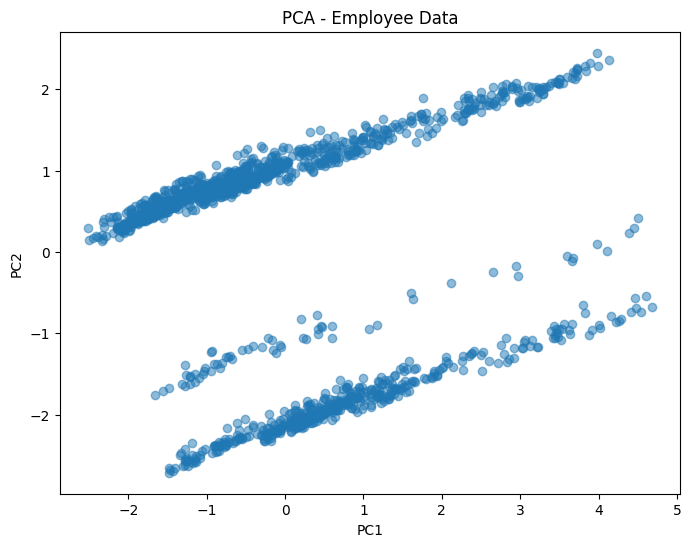

In [35]:
# plot the data
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - Employee Data')
plt.show()

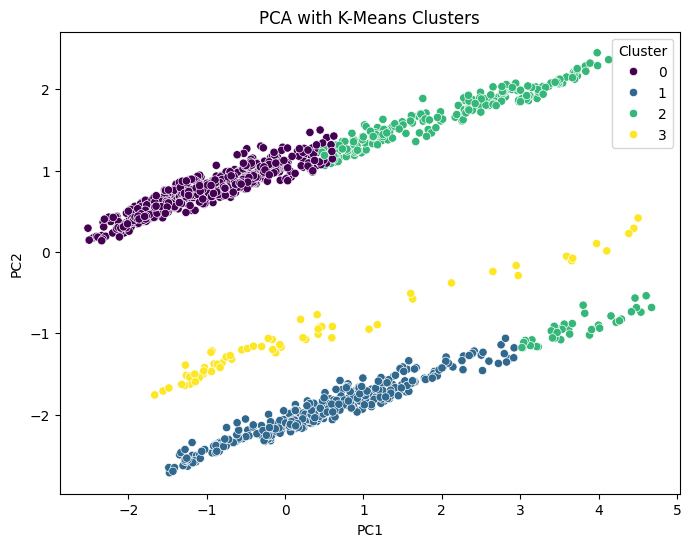

In [36]:
# overlay the kmeans clusters (hint: set the hue to be the cluster labels)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=labels, palette='viridis')
plt.title('PCA with K-Means Clusters')
plt.legend(title='Cluster')
plt.show()

### c. Overlay the Department colors instead

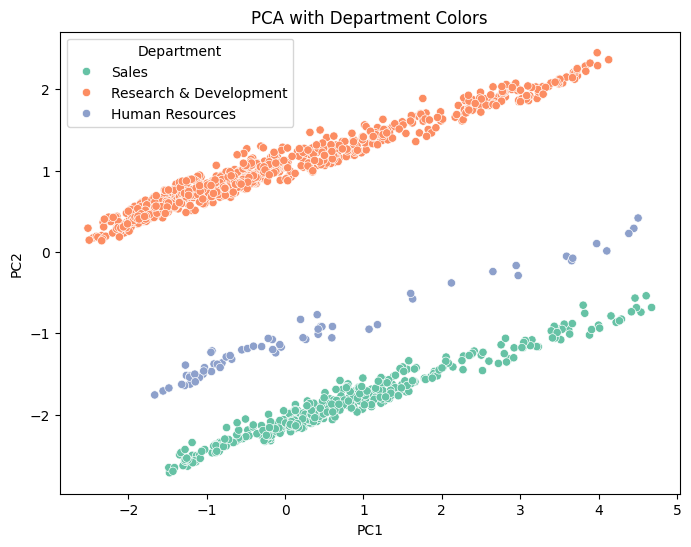

In [37]:
# overlay the department colors (hint: set the hue to be the department column)
department_series = df_clean[['Dept_Human Resources', 'Dept_Research & Development', 'Dept_Sales']].idxmax(axis=1)
department_series = department_series.str.replace('Dept_', '')

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=department_series, palette='Set2')
plt.title('PCA with Department Colors')
plt.legend(title='Department')
plt.show()

## 4. K-Means Clustering: Round 2

Since the departments seemed to dominate the visualization, let's exclude them and try fitting more K-Means models.

### a. Create a new dataframe without the Departments

In [38]:
# create a new dataframe that excludes the three department columns from the scaled dataframe
df_no_dept = df_scaled.drop(['Dept_Human Resources', 'Dept_Research & Development', 'Dept_Sales'], axis=1)
print(f"Shape without departments: {df_no_dept.shape}")

Shape without departments: (1470, 7)


### b. Write a loop to fit models with 2 to 15 clusters and record the inertia and silhouette scores

In [39]:
# write a loop to fit models with 2 to 15 clusters
inertia_no_dept = []
silhouette_no_dept = []
k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_no_dept)
    inertia_no_dept.append(kmeans.inertia_)
    silhouette_no_dept.append(silhouette_score(df_no_dept, kmeans.labels_))

Text(0.5, 1.0, 'Elbow Method (No Departments)')

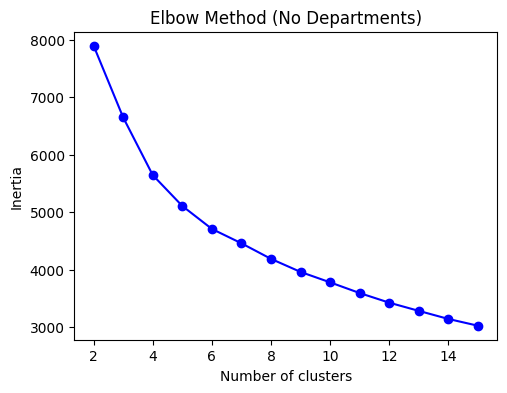

In [40]:
# plot the inertia values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia_no_dept, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method (No Departments)')

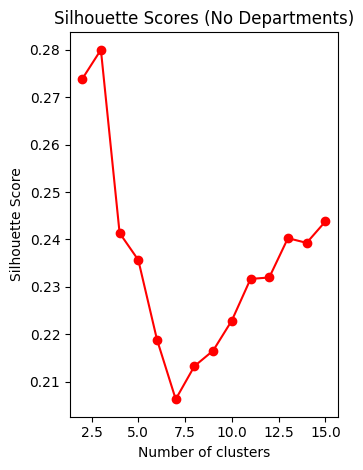

In [41]:
# plot the silhouette scores
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_no_dept, 'ro-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores (No Departments)')
plt.tight_layout()
plt.show()

### c. Identify a few k values that looks like an elbow on the inertia plot and have a high silhouette score

#### i. k = 4

In [42]:
# fit a kmeans model for the k value that you identified
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_4 = kmeans_4.fit_predict(df_no_dept)

In [43]:
# find the number of employees in each cluster
print("Employees per cluster (k=4):", pd.Series(labels_4).value_counts().sort_index())

Employees per cluster (k=4): 0    405
1    249
2    616
3    200
Name: count, dtype: int64


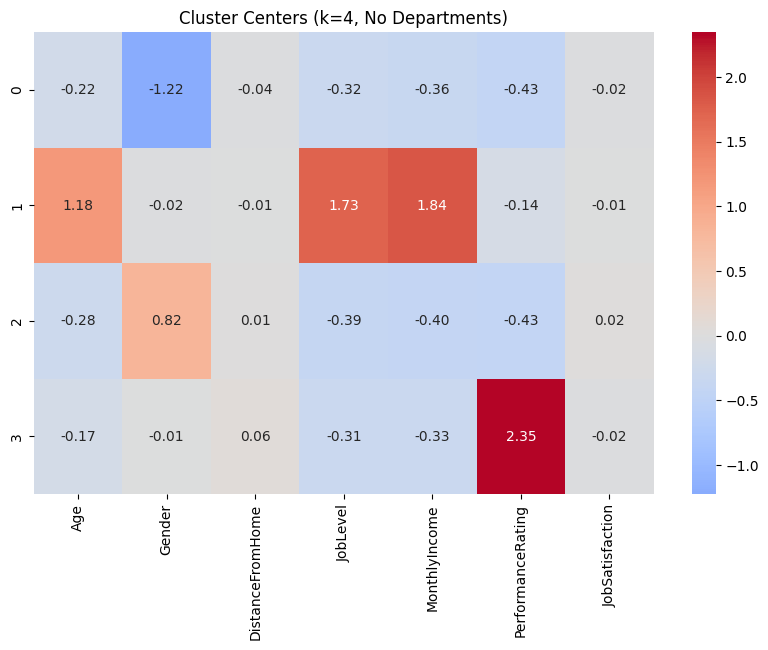

In [44]:
# create a heat map of the cluster centers
cluster_centers_4 = pd.DataFrame(kmeans_4.cluster_centers_, columns=df_no_dept.columns)
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_centers_4, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Cluster Centers (k=4, No Departments)')
plt.show()

# Cluster Interpretation (k = 4, No Departments)

# Cluster 0 – Low-Performing Female Employees
 - Characterized by low gender values (primarily female), below-average performance ratings, and low monthly income.
 - Typically occupy entry-level or early-career positions with limited advancement so far.
 - Reflects a group that may benefit from targeted skill development, mentorship, and performance improvement initiatives.
 - Represents a potential area for HR focus to improve engagement and upward mobility among female employees.

# Cluster 1 – Senior High-Income Executives
 - Defined by high job levels, strong positive income values, and higher age, marking experienced and well-established employees.
 - Represents the organization’s top leadership or senior management segment.
 - This group shows stable performance and compensation aligned with senior roles.
 - Plays a critical role in strategic direction and organizational decision-making.

# Cluster 2 – Low-Performing Male Employees
 - Identified by high gender values (mostly male), low performance ratings, and low income.
 - Likely composed of entry-level or mid-level employees struggling with performance or motivation.
 - Could reflect an underperforming demographic that requires targeted performance management or training interventions.
 - May benefit from clearer growth pathways and incentive structures.

# Cluster 3 – High-Performing Junior Employees
 - Distinguished by very high performance ratings but relatively low income and job level.
 - Likely represents younger or early-career employees showing strong potential and high engagement.
 - Suggests promising emerging talent that might be under-compensated compared to their contribution.
 - Key retention and reward programs could help prevent turnover among this high-performing group.

# Summary:
# - Cluster 0 and 2 reveal two distinct underperforming segments divided by gender.
# - Cluster 1 represents the organization’s high-level management tier.
# - Cluster 3 highlights high-performing but underpaid junior staff.
# - Together, these clusters provide actionable insight into workforce segmentation — identifying both at-risk and high-potential employee groups for strategic HR planning.


#### ii. k = 6

In [45]:
# fit a kmeans model for the k value that you identified
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_6 = kmeans_6.fit_predict(df_no_dept)

In [46]:
# find the number of employees in each cluster
print("Employees per cluster (k=6):", pd.Series(labels_6).value_counts().sort_index())

Employees per cluster (k=6): 0    304
1    200
2    197
3    349
4    219
5    201
Name: count, dtype: int64


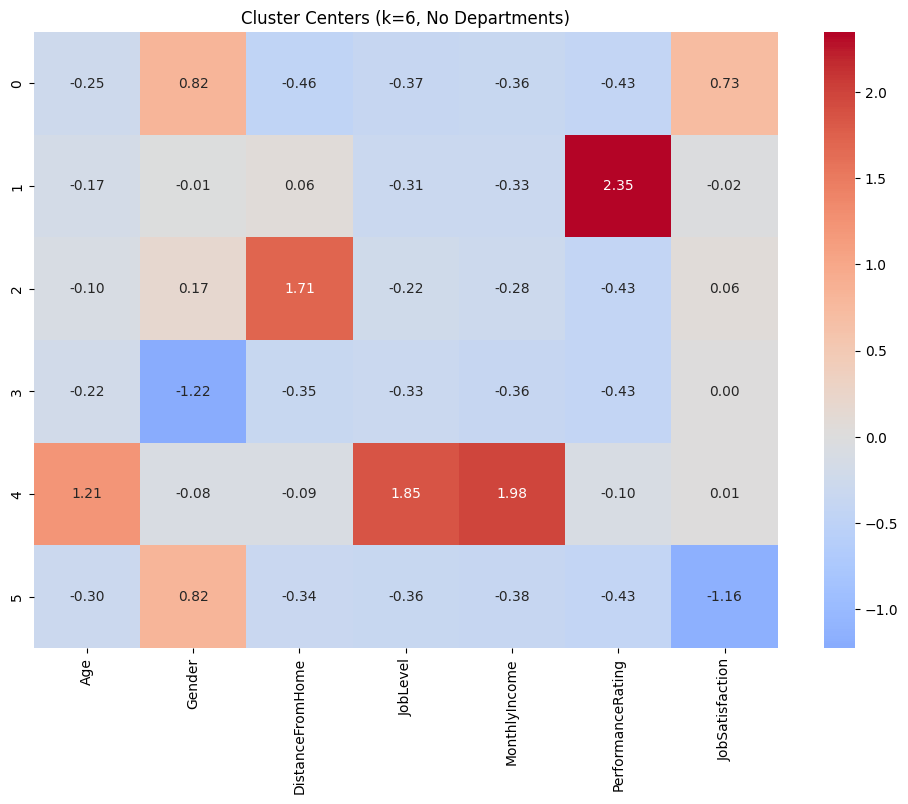

In [47]:
# create a heat map of the cluster centers
cluster_centers_6 = pd.DataFrame(kmeans_6.cluster_centers_, columns=df_no_dept.columns)
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_centers_6, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Cluster Centers (k=6, No Departments)')
plt.show()

# Cluster Interpretation (k = 6, No Departments)

# Cluster 0 – Satisfied Male Commuters
- Comprised mainly of male employees with high job satisfaction and shorter commute distances.
 - Exhibit moderate income and job levels, suggesting a stable mid-tier workforce.
 - Represent well-adjusted, locally based male staff with strong workplace engagement.
 - This group shows balanced performance and satisfaction, indicating low turnover risk.

# Cluster 1 – High-Performing Junior Staff
 - Young employees with strong performance ratings but lower job levels and income.
 - Demonstrate high motivation and productivity, yet remain under-compensated relative to their contribution.
 - Reflect promising early-career talent that could advance rapidly with proper recognition and growth opportunities.
 - At risk of attrition if career development or pay progression is not addressed.

# Cluster 2 – Long-Distance Commuters
 - Employees with higher commute distances, lower performance scores, and below-average income.
 - Geographic distance from work may negatively influence performance and engagement.
 - Likely include lower-level employees facing fatigue or productivity issues tied to commuting challenges.
 - Support programs such as flexible scheduling or remote work options could improve retention and output.

# Cluster 3 – Low-Performing Female Employees
 - Dominated by female employees with low job level, low income, and reduced performance ratings.
 - Possibly entry-level or mid-level staff experiencing slower career progression.
 - May require performance coaching, mentoring, or targeted development initiatives to improve outcomes.
 - Represent an important demographic for diversity, inclusion, and career advancement support.

# Cluster 4 – Senior Leadership Group
 - Characterized by very high job levels, top income brackets, and older average age.
 - Represents the organization’s executive or senior management tier responsible for strategy and decision-making.
 - Stable performance and satisfaction scores indicate strong alignment with organizational goals.
 - Essential for leadership continuity, mentorship, and driving company performance.

# Cluster 5 – Dissatisfied Male Employees
 - Mostly male employees showing low job satisfaction and poor performance ratings.
 - Income and job levels are below average, suggesting possible stagnation or disengagement.
 - Represents a high-risk group for turnover or productivity loss.
 - May benefit from targeted re-engagement strategies, performance feedback, and workload adjustments.

# Summary:
# - Cluster 0 and Cluster 1 reflect engaged and high-performing employees at different career stages.
# - Cluster 2 and Cluster 5 highlight groups with performance and satisfaction challenges linked to distance or disengagement.
# - Cluster 3 captures underperforming female employees needing structured career support.
# - Cluster 4 represents senior leadership, the most stable and high-value segment.
# - Overall, the segmentation reveals actionable insights for improving performance, retention, and career development across distinct employee categories.


#### iii. k = 3

In [48]:
# fit a kmeans model for the k value that you identified
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(df_no_dept)

In [49]:
# find the number of employees in each cluster
print("Employees per cluster (k=3):", pd.Series(labels_3).value_counts().sort_index())

Employees per cluster (k=3): 0    200
1    988
2    282
Name: count, dtype: int64


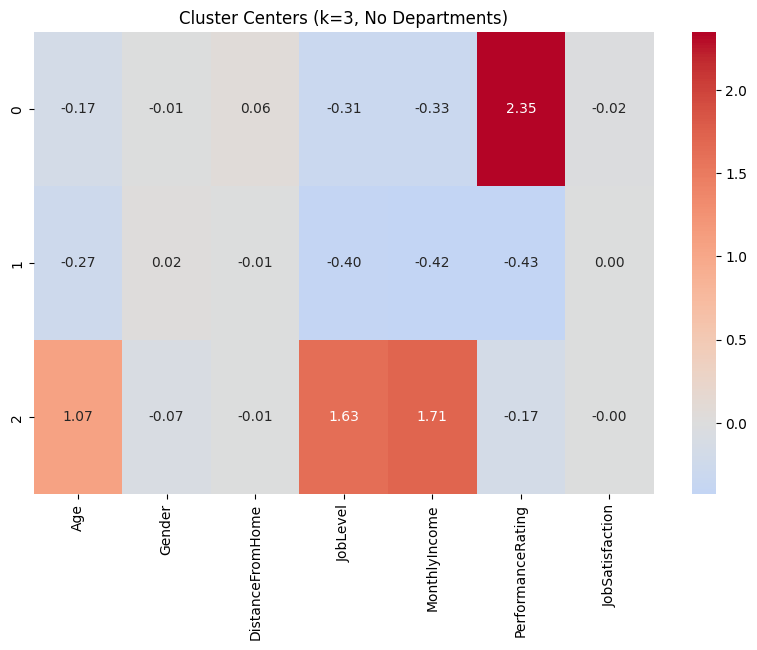

In [50]:
# create a heat map of the cluster centers
cluster_centers_3 = pd.DataFrame(kmeans_3.cluster_centers_, columns=df_no_dept.columns)
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_centers_3, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Cluster Centers (k=3, No Departments)')
plt.show()

# Cluster Interpretation (k = 3, No Departments)

# Cluster 0 – High-Performing Junior Employees
- Defined by very high performance ratings, despite lower job levels and modest income.
 - Likely represents younger or early-career staff demonstrating strong productivity and engagement.
 - Employees in this group are high-potential individuals who could advance quickly with proper career development.
 - Target group for leadership training, promotion pathways, and retention programs.

# Cluster 1 – General Low Performers
 - Characterized by low performance, low income, and lower job levels across all metrics.
 - Represents employees who may struggle with engagement, productivity, or skill alignment.
 - This group would benefit from targeted coaching, re-skilling initiatives, and performance management.
 - Indicates a potential area for HR intervention to improve organizational efficiency and morale.

# Cluster 2 – Senior High Earners
 - Composed of experienced, older employees with the highest job levels and income.
 - Reflects established professionals or company leaders occupying senior or executive roles.
 - Consistent performance and stable satisfaction levels suggest a reliable and experienced segment.
 - Plays a key role in mentorship, decision-making, and organizational strategy.

# Summary:
# - Cluster 0 identifies high-performing yet underpaid junior talent — a key retention priority.
# - Cluster 1 highlights a broad group of underperformers needing training or motivation.
# - Cluster 2 represents senior, well-compensated employees forming the leadership backbone.
# - Overall, this segmentation differentiates the workforce by experience, performance, and compensation,
#   providing actionable insights for career development and HR planning.


## 5. PCA: Round 2

Let's visualize the data (without Departments) using PCA.

### a. Fit a PCA Model with 2 components for visualization

In [51]:
# fit a PCA model with 2 components
pca_no_dept = PCA(n_components=2)
pca_components_no_dept = pca_no_dept.fit_transform(df_no_dept)

In [52]:
# view the explained variance ratio
print(f"Explained variance ratio: {pca_no_dept.explained_variance_ratio_}")

Explained variance ratio: [0.33354222 0.14850324]


In [53]:
# view the components
print("PCA Components:", pca_no_dept.components_)

PCA Components: [[ 0.47124275 -0.0460627  -0.00629691  0.62393147  0.62140377 -0.01687984
  -0.00712661]
 [-0.01896906  0.58615904 -0.41405416  0.01838822  0.02778096 -0.4833175
   0.49991119]]


In [54]:
# view the columns
print("Columns:", df_no_dept.columns.tolist())

Columns: ['Age', 'Gender', 'DistanceFromHome', 'JobLevel', 'MonthlyIncome', 'PerformanceRating', 'JobSatisfaction']


# PCA Interpretation (Round 2, No Department Variables)

# PC1 – Career Progression and Experience Axis (33.4% Variance Explained)
 - Strong positive loadings on JobLevel, MonthlyIncome, and Age indicate this component captures
   an employee’s career maturity and earning power.
 - Higher PC1 scores correspond to senior or long-tenured employees with higher positions and compensation.
 - Lower PC1 scores represent junior or early-career employees with lower income and limited experience.
 - This axis effectively separates the workforce by professional growth and advancement stage.

# PC2 – Gender and Satisfaction Axis (14.9% Variance Explained)
 - Dominant contributions from Gender (positive), JobSatisfaction (positive), and negative influence from PerformanceRating.
 - Reflects differences in job perception and engagement — distinguishing groups based on satisfaction levels and gender distribution.
 - Higher PC2 scores likely correspond to satisfied male employees, whereas lower scores may represent high-performing
   but less satisfied individuals.
 - This axis captures attitudinal and behavioral variation within the workforce rather than career level.

# Summary:
# - PC1 represents structural progression (seniority, income, and experience).
# - PC2 represents attitudinal variation (gender-linked satisfaction and performance trends).
# - Together, these two components summarize nearly 48.2% of the dataset’s variance,
#   providing clear insight into hierarchical and psychological differences across employees.


### b. Overlay the K-Means cluster colors

In [55]:
# transform the data
pca_df_no_dept = pd.DataFrame(pca_components_no_dept, columns=['PC1', 'PC2'])

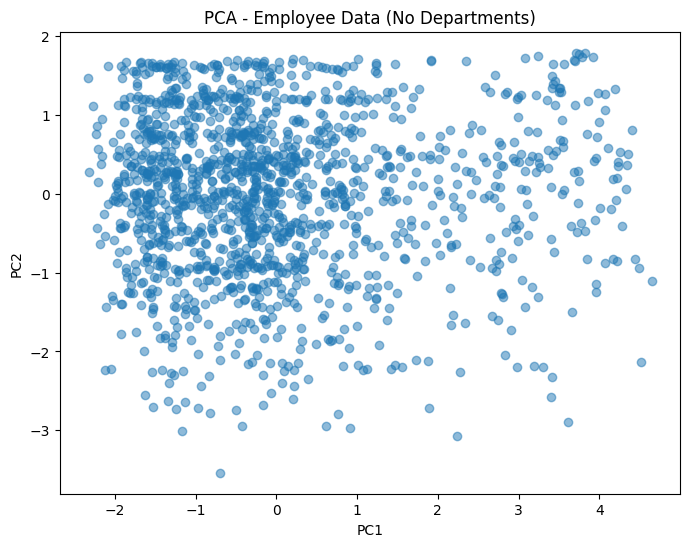

In [56]:
# plot the data
plt.figure(figsize=(8, 6))
plt.scatter(pca_df_no_dept['PC1'], pca_df_no_dept['PC2'], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - Employee Data (No Departments)')
plt.show()

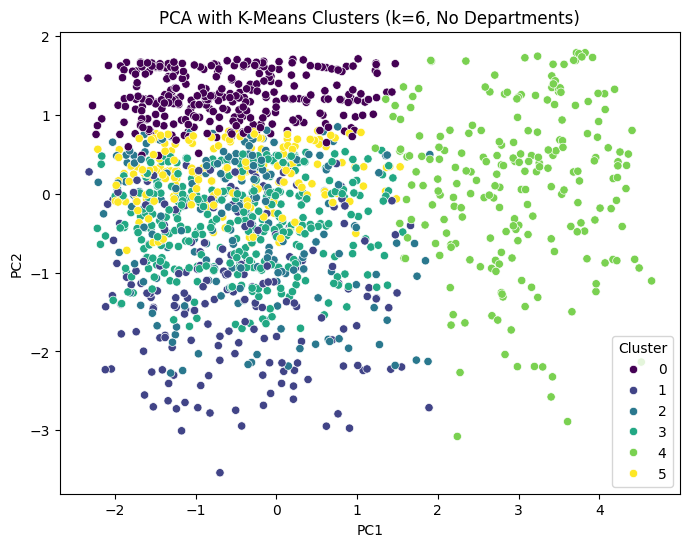

In [57]:
# overlay the kmeans clusters (choose your favorite k-means model from the previous section)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df_no_dept, x='PC1', y='PC2', hue=labels_6, palette='viridis')
plt.title('PCA with K-Means Clusters (k=6, No Departments)')
plt.legend(title='Cluster')
plt.show()

### c. OPTIONAL: Create a 3D plot

In [58]:
# fit a PCA model with 3 components
pca_3d = PCA(n_components=3)
pca_components_3d = pca_3d.fit_transform(df_no_dept)

In [59]:
# view the explained variance ratio
print(f"Explained variance ratio: {pca_3d.explained_variance_ratio_}")

Explained variance ratio: [0.33354222 0.14850324 0.14578114]


In [60]:
# view the components
print("PCA Components:", pca_3d.components_)

PCA Components: [[ 0.47124275 -0.0460627  -0.00629691  0.62393147  0.62140377 -0.01687984
  -0.00712661]
 [-0.01896906  0.58615904 -0.41405416  0.01838822  0.02778096 -0.4833175
   0.49991119]
 [ 0.02702996  0.36313603  0.55488385  0.02159616  0.01065236  0.52050007
   0.53666127]]


In [61]:
# view the columns
print(df_no_dept.columns.tolist())

['Age', 'Gender', 'DistanceFromHome', 'JobLevel', 'MonthlyIncome', 'PerformanceRating', 'JobSatisfaction']


# PCA Interpretation (3 Components – 3D Visualization)

# PC1 – Career Progression and Seniority Axis (33.3% Variance Explained)
- Dominated by strong positive weights for JobLevel, MonthlyIncome, and Age.
 - Represents an employee’s career advancement and professional standing within the company.
 - Higher PC1 scores correspond to experienced, well-compensated senior staff; lower scores reflect junior or early-stage employees.
 - This is the primary structural dimension of the dataset, capturing hierarchical differences in role and compensation.

# PC2 – Gender and Satisfaction Dynamics Axis (14.8% Variance Explained)
 - Driven by positive loadings from Gender and JobSatisfaction, with a negative contribution from PerformanceRating.
 - Describes variations in employee attitudes and engagement patterns linked to gender and satisfaction levels.
 - Higher PC2 scores indicate employees who are more satisfied and predominantly male,
   whereas lower scores reflect high-performing individuals who may experience reduced satisfaction.
 - Captures psychological and behavioral contrasts across the workforce.

# PC3 – Commute and Performance Resilience Axis (14.6% Variance Explained)
 - Positively influenced by DistanceFromHome, JobSatisfaction, and PerformanceRating.
 - Reflects an employee’s ability to sustain high satisfaction and performance despite longer commute distances.
 - Highlights individuals who maintain engagement and productivity regardless of external logistical challenges.
 - Represents a resilience or adaptability dimension, emphasizing personal motivation and job commitment.

# Summary:
# - PC1 maps career level and organizational seniority.
# - PC2 represents gender-driven satisfaction and performance trade-offs.
# - PC3 reveals resilience under commuting and work balance pressures.
# - Together, these three components explain approximately 63% of total variance, providing a comprehensive multi-dimensional view
#   of employee structure, engagement, and adaptability within the company.


In [62]:
# transform the data
pca_df_3d = pd.DataFrame(pca_components_3d, columns=['PC1', 'PC2', 'PC3'])

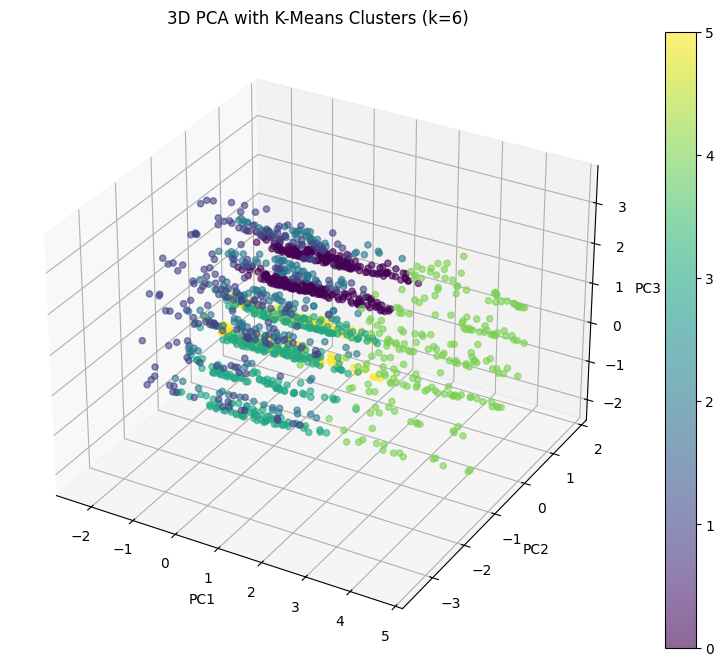

In [63]:
# create a 3d scatter plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_df_3d['PC1'], pca_df_3d['PC2'], pca_df_3d['PC3'],
                     c=labels_6, cmap='viridis', alpha=0.6)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA with K-Means Clusters (k=6)')
plt.colorbar(scatter)
plt.show()

## 6. EDA on Clusters

Let's decide to go with the 6 clusters without department data.

### a. Confirm the 6 clusters

In [64]:
# fit a kmeans model with 6 clusters
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
final_labels = kmeans_final.fit_predict(df_no_dept)

In [65]:
# view the cluster labels
print("Final cluster labels distribution:", pd.Series(final_labels).value_counts().sort_index())

Final cluster labels distribution: 0    304
1    200
2    197
3    349
4    219
5    201
Name: count, dtype: int64


### b. Create a dataframe with the cluster labels and names

In [66]:
# create a dataframe with two columns - one of the label and another of the cluster name
cluster_labels_df = pd.DataFrame({'label': final_labels})
# create a mapping for the cluster names
cluster_names = {
    0: "Satisfied Male Commuters",
    1: "High-Performing Junior Staff",
    2: "Long-Distance Commuters",
    3: "Low-Performing Female Employees",
    4: "Senior Leadership",
    5: "Dissatisfied Male Employees"
}
# combine the labels and names into a single dataframe
cluster_labels_df['cluster_name'] = cluster_labels_df['label'].map(cluster_names)
print(cluster_labels_df['cluster_name'].value_counts())

cluster_name
Low-Performing Female Employees    349
Satisfied Male Commuters           304
Senior Leadership                  219
Dissatisfied Male Employees        201
High-Performing Junior Staff       200
Long-Distance Commuters            197
Name: count, dtype: int64


### c. View the attrition rates for each cluster

In [67]:
# combine the clusters and attrition data
cluster_attrition_df = pd.DataFrame({
    'cluster': final_labels,
    'cluster_name': cluster_labels_df['cluster_name'],
    'attrition': df_clean['Attrition']
})

In [68]:
# what is the attrition rate for each cluster?
attrition_by_cluster = cluster_attrition_df.groupby('cluster_name')['attrition'].agg(['mean', 'count'])
attrition_by_cluster.columns = ['attrition_rate', 'employee_count']

In [69]:
# sort the values
attrition_by_cluster = attrition_by_cluster.sort_values('attrition_rate', ascending=False)
print("Attrition rates by cluster:", attrition_by_cluster)

Attrition rates by cluster:                                  attrition_rate  employee_count
cluster_name                                                   
Long-Distance Commuters                0.218274             197
Dissatisfied Male Employees            0.189055             201
High-Performing Junior Staff           0.185000             200
Satisfied Male Commuters               0.161184             304
Low-Performing Female Employees        0.154728             349
Senior Leadership                      0.073059             219


# Attrition Analysis by Cluster – Interpretation

# High-Risk Clusters (Attrition ≥ 15%)

# Long-Distance Commuters – 21.8% attrition
- This group faces the highest turnover rate, likely driven by the burden of long commutes and reduced work-life balance.
 - Geographic distance appears to negatively impact engagement and retention.
 - Flexible work arrangements or location-based incentives could help mitigate this issue.

# Dissatisfied Male Employees – 18.9% attrition
 - Job dissatisfaction is the primary factor influencing exits within this group.
 - Low morale and disengagement increase the likelihood of turnover despite moderate experience levels.
 - Intervention through career path clarity, feedback programs, or incentive adjustments may improve retention.

# High-Performing Junior Staff – 18.5% attrition
 - High-potential employees in junior roles are leaving due to limited advancement or compensation growth.
 - Represents a critical talent segment at risk of attrition if recognition or promotion opportunities are lacking.
 - Focused talent development and accelerated career progression programs are recommended.

# Satisfied Male Commuters – 16.1% attrition
 - Although generally satisfied, moderate attrition suggests that satisfaction alone does not fully ensure retention.
 - Other factors such as workload balance or external opportunities might contribute to exits.

# Low-Performing Female Employees – 15.5% attrition
 - Turnover here is linked to lower performance and possibly reduced engagement.
 - This segment may require stronger managerial support, coaching, or performance improvement initiatives.

# Low-Risk Cluster (Attrition < 10%)

# Senior Leadership – 7.3% attrition
 - This group shows the lowest turnover rate, representing a highly stable and well-compensated executive cohort.
 - Retention is strong due to seniority, job satisfaction, and alignment with company goals.
 - Indicates effective engagement and reward structures among experienced leaders.

# Summary:
# - The highest attrition is concentrated among employees facing long commutes, job dissatisfaction, or limited career growth.
# - Senior leaders demonstrate the strongest stability.
# - Strategic focus should be placed on enhancing flexibility, engagement, and development programs for high-risk and high-potential groups.


In [70]:
# find the number of employees in each cluster
print(attrition_by_cluster['employee_count'])

cluster_name
Long-Distance Commuters            197
Dissatisfied Male Employees        201
High-Performing Junior Staff       200
Satisfied Male Commuters           304
Low-Performing Female Employees    349
Senior Leadership                  219
Name: employee_count, dtype: int64


### d. View the department breakdown for each cluster

In [71]:
# combine the clusters and department data
cluster_dept_df = pd.DataFrame({
    'cluster': final_labels,
    'cluster_name': cluster_labels_df['cluster_name'],
    'attrition': df_clean['Attrition']
})
dept_series = df_clean[['Dept_Human Resources', 'Dept_Research & Development', 'Dept_Sales']].idxmax(axis=1)
cluster_dept_df['department'] = dept_series.str.replace('Dept_', '')

In [72]:
# what is the attrition rate for each cluster + department combination?
attrition_by_cluster_dept = cluster_dept_df.groupby(['cluster_name', 'department'])['attrition'].agg(['mean', 'count'])
attrition_by_cluster_dept.columns = ['attrition_rate', 'employee_count']

In [73]:
# sort the values
attrition_by_cluster_dept = attrition_by_cluster_dept.sort_values('attrition_rate', ascending=False)
print("Attrition rates by cluster and department:")
print(attrition_by_cluster_dept.head(10))

Attrition rates by cluster and department:
                                                        attrition_rate  \
cluster_name                    department                               
Long-Distance Commuters         Human Resources               0.666667   
                                Sales                         0.311475   
Low-Performing Female Employees Human Resources               0.300000   
Dissatisfied Male Employees     Sales                         0.215385   
                                Human Resources               0.214286   
Low-Performing Female Employees Sales                         0.206897   
Satisfied Male Commuters        Sales                         0.193548   
High-Performing Junior Staff    Research & Development        0.188406   
                                Sales                         0.181818   
Dissatisfied Male Employees     Research & Development        0.172131   

                                                        employee_cou

### interpret the findings

# Attrition by Cluster and Department – Summary Interpretation

# Long-Distance Commuters in HR – 66.7% attrition
- Extremely high turnover despite small sample size (6 employees).
 - Commute fatigue and limited flexibility are key issues.
 - Remote or hybrid options could immediately reduce attrition.

# Long-Distance Commuters in Sales – 31.1% attrition
 - High commute and sales pressure jointly drive turnover.
 - Territory realignment or flexible work hours may help retention.

# Low-Performing Female Employees in HR – 30.0% attrition
 - Combined risk from low performance and HR job stress.
 - Mentorship and targeted training could support engagement and improvement.

# Dissatisfied Male Employees in Sales – 21.5% attrition
 - Job dissatisfaction intensified by high-pressure sales environments.
 - Performance incentives or rotation programs could improve morale.

# Summary:
 - Highest attrition occurs where commute burden, job stress, and performance issues overlap.
 - HR and Sales departments show the greatest vulnerability.
 - Addressing flexibility, engagement, and development can effectively reduce turnover in these groups.


In [74]:
# find the number of employees in each cluster + department combo
print(attrition_by_cluster_dept['employee_count'].sort_values(ascending=False).head(10))

cluster_name                     department            
Low-Performing Female Employees  Research & Development    223
Satisfied Male Commuters         Research & Development    197
Senior Leadership                Research & Development    151
High-Performing Junior Staff     Research & Development    138
Long-Distance Commuters          Research & Development    130
Dissatisfied Male Employees      Research & Development    122
Low-Performing Female Employees  Sales                     116
Satisfied Male Commuters         Sales                      93
Dissatisfied Male Employees      Sales                      65
Long-Distance Commuters          Sales                      61
Name: employee_count, dtype: int64


## 7. Make Recommendations

In [ ]:
# looking at the clusters, what segment info would you share with the team?


# Interpretation 1 – Segment Overview to Share with the Team

 The cluster analysis revealed six major employee segments, each demonstrating distinct behavioral and attrition patterns.

 The most critical concern lies with the Long-Distance Commuters, who show the highest overall attrition rate at 21.8%.

Within this group, HR employees face an alarming 66.7% turnover rate, indicating that commute-related fatigue,
 lack of flexibility, and potential work-life imbalance are major contributing factors.

 Following closely are the Dissatisfied Male Employees (18.9%) and High-Performing Junior Staff (18.5%),
 both representing key but contrasting challenges  disengaged employees versus high-potential talent attrition.

 A particularly concerning trend is that high-performing junior staff are leaving at nearly the same rate
 as underperforming or dissatisfied groups. This suggests that strong performance and engagement are insufficient
 to ensure retention when employees do not see tangible career advancement or compensation progression.

 The Sales department exhibits consistently higher turnover rates across multiple clusters,
 which implies department-specific issues such as high performance pressure, workload imbalance, or inadequate support structures.

 Addressing these root causes at both the departmental and organizational levels is essential to improve retention
 and prevent the loss of valuable employees across different career stages.




In [75]:
# what recommendations would you suggest to retain employees in each cluster?



# Interpretation 2 – Recommendations to Retain Employees by Cluster

# Long-Distance Commuters:
 - Implement a comprehensive flexible work program allowing 2–3 remote workdays per week to reduce commuting stress.
 - Explore options such as transportation reimbursements, satellite office spaces, and compressed workweeks
   to improve convenience and work-life balance.
 - The HR subgroup with a 66.7% attrition rate requires urgent intervention — including workload reassessment,
   better communication, and remote policy prioritization to reduce fatigue and disengagement.

# Dissatisfied Male Employees:
 - Conduct targeted stay interviews and satisfaction surveys to identify the underlying reasons for disengagement.
 - Introduce personalized career progression plans, skill-building programs, and regular managerial feedback sessions
   to re-establish trust and motivation.
 - In Sales, reassess commission structures, workload expectations, and performance targets
   to ensure goals are realistic and aligned with well-being.

# High-Performing Junior Staff:
 - Develop structured mentorship and talent development frameworks connecting high-potential employees with senior leaders.
 - Provide clear advancement pathways and milestone-based incentives to retain promising young professionals.
 - Address R&D’s 18.8% attrition rate by creating recognition systems for innovation and contribution,
   helping employees see a tangible link between performance and reward.

# Organization-Wide Strategies:
 - Conduct a department-level audit of HR and Sales practices, focusing on workload distribution,
   leadership effectiveness, and cultural pressures contributing to turnover.
 - Introduce a continuous feedback system through pulse surveys and quarterly engagement reviews
   to track satisfaction and identify risks early.
 - Encourage leadership accountability in employee development and retention by setting measurable retention KPIs.
 - Strengthen internal communication channels, ensuring employees feel recognized, supported, and connected
   to long-term organizational goals.
